# Tarea 1: Descenso del Gradiente y Backpropagation
## Objetivos
- Aprender sobre conceptos de
- Estudiar aspectos teóricos de redes neuronales
- Comprender los componentes de la implementación de backpropagation.


# Contexto
La base de datos consiste en una secuencia de  trayectorias de objetos entrando en un espacio aéreo. Está encargado de desarrollar un sistema de estimación temprana de trayectorias. Cada trayectoria está definida por la coordenada GPS X0 y X1, en distintos tiempos $T_1, T_2, … , T_N$. Y la coordinación futura que se busca predecir “X” y “Y”.
Dado que las mediciones se hacen a partir de un radar anticuado, las posiciones medidas $T_ix_j$ pueden tener errores en el rango de varios kilómetros. Sin embargo, las coordenadas “X” y “Y” se calculan con GPS y no tienen errores.


# Parte 1: Exploración
1. Explore los datos
2. Defina una función para graficar un número N de trayectorias.
3. Normalice los datos [0,1].


In [2]:
import numpy as np
import pandas as pd
import numpy.typing as npt
import matplotlib.pyplot as plt

data = pd.read_csv('../data/data_tarea1.csv')
data.sample(4)

,T0_x0,T0_x1,T1_x0,T1_x1,T2_x0,T2_x1,T3_x0,T3_x1,T4_x0,T4_x1,...,T8_x0,T8_x1,T9_x0,T9_x1,T10_x0,T10_x1,T11_x0,T11_x1,X,Y
264,238.0,32.0,233.0,36.0,230.0,41.0,226.0,47.0,219.0,50.0,...,200.0,68.0,196.0,74.0,189.0,86.0,184.0,84.0,165.0,106.0
32,168.0,256.0,169.0,254.0,174.0,250.0,177.0,245.0,178.0,242.0,...,200.0,219.0,200.0,221.0,207.0,218.0,209.0,213.0,227.0,197.0
500,187.0,209.0,179.0,206.0,169.0,201.0,162.0,192.0,150.0,180.0,...,117.0,162.0,106.0,149.0,98.0,142.0,90.0,135.0,53.0,109.0
572,266.0,284.0,262.0,283.0,260.0,283.0,261.0,281.0,258.0,279.0,...,248.0,274.0,243.0,271.0,246.0,272.0,245.0,274.0,236.0,269.0


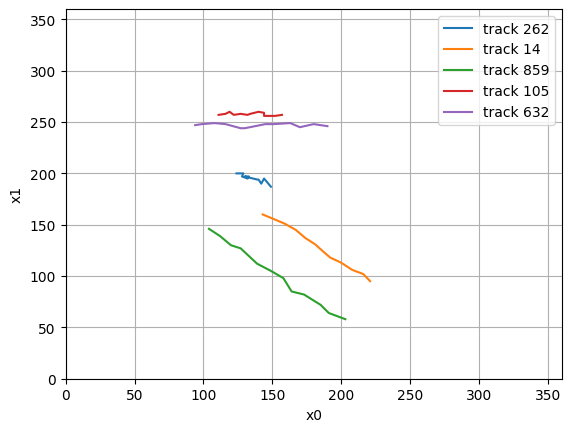

In [3]:

def plot_trajectories(data, n_trajectories=5):
    ### CODE HERE

plot_trajectories(data,5)

In [4]:
### CODE HERE
print('range data: {:.4f} - {:.4f}'.format(data_values.min(),data_values.max()))
output = data.values[:,-2:]/ 360
print('range output: {:.4f} - {:.4f}'.format(output.min(),output.max()))
print('data shape = ',data_values.shape)

range data: -0.0139 - 1.0056
range output: 0.0028 - 0.9972
data shape =  (1000, 24)


# Parte 2: Teoría
1. Dada una red neuronal de una capa y múltiples neuronas definida por las ecuaciones:
$$
z_1=bias + \sum_{i=1}^n a_i x_i
$$


$$
u_1=\sigma(z_1)
$$


$$
\overline{y}= f(u_1)
$$


$$
L(x) =(y - \overline{y})^2 \alpha
$$
Donde L es la función de perdida a optimizar y $\alpha$ es el learning rate. Determine una expresión para la derivada de la función de perdida con respecto a los pesos de la red.

![muti_input_single_layer_network.jpeg](images/muti_input_single_layer_network.jpeg)



2. Dada una red neuronal de múltiples capas y una neurona por cada definida por las ecuaciones:
$$
u_0=x
$$


$$
z_i= u_{i-1} * a_i + b_i
$$


$$
u_i = \sigma(z_i)
$$


$$
\overline{y}= u_n
$$


$$
L(x) =(y - \overline{y})^2 \alpha
$$
Determine una expresión para la derivada de la función de perdida con respecto a los pesos de la red.
![single_input_multi_layer_network.jpeg](images/single_input_multi_layer_network.jpeg)

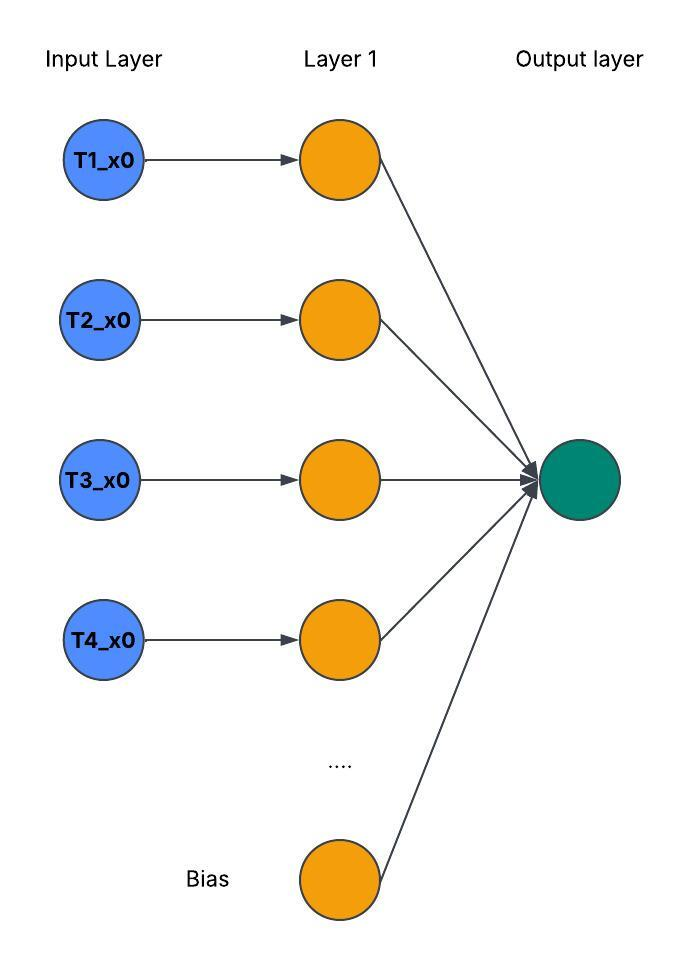

## Parte 3: Implementación de modelos de redes neuronales. 
- Implemente una red neuronal de una sola capa, y múltiples inputs. 
- Implemente una red neuronal de múltiples capas y un solo input. 
- Implemente una clase para la función de activación sigmoide.
- Verifique que las dimensiones de entrada y salida se cumplen con la funcion test_dimensions. 
- Entre una red neuronal de cada tipo la función de activación sigmoide. Para ello escoja alguna de las dos variables a predecir (“X” o “Y”), y define qué atributos son relevantes para el entrenamiento. 
- Evalúe el error de las predicciones a través del MSE. 
- Escoja una red y realice un entrenamiento con la función de activación ReLU. 


In [5]:
class MSE:
    def __init__(self, learning_rate=0.5):
        self.last_y_pred = None
        self.learning_rate = learning_rate
    def forward(self, y: npt.NDArray[np.float32|np.float64] ,
                y_pred: npt.NDArray[np.float32|np.float64] ) -> npt.NDArray[np.float32|np.float64]:
        self.last_y_pred = y_pred
        self.last_y  = y
        return (y-y_pred)**2 * self.learning_rate

    def backward(self, )-> npt.NDArray[np.float32|np.float64]:
        return (self.last_y - self.last_y_pred) * 2 * self.learning_rate * -1

    def __str__(self):
        return "MSE input = {:.4f}, derivative = {:.4f}".format(self.last_y_pred, self.last_y_pred * 2 * self.learning_rate)



class Sigmoid:
    def __init__(self):
        self.last_output = None

    def forward(self,x):
        ### CODE HERE

    def backward(self, derivative):
        ### CODE HERE

class ReLU:
    def __init__(self):
        self.derivative = None

    def forward(self,x):
        derivative = np.empty(len(x))
        for i,x_input in enumerate(x):

            if x_input > 0:
                derivative[i] = 1
            else:
                derivative[i] = 0
        self.derivative = derivative
        return np.maximum(x,0)

    def backward(self, derivative):
        return self.derivative * derivative

class MultiInputSingleLayerNetwork:
    def __init__(self, n_inputs: int, activation_function):
        self.weights = np.random.uniform(-2,2,n_inputs)
        self.bias = np.random.uniform(-2,2)
        self.last_x = None
        self.activation_function = activation_function

    def forward(self,x):
        ### CODE HERE

    def backward(self, derivative):

        ### CODE HERE

    def copy(self):
        model = MultiInputSingleLayerNetwork(self.n_layers,self.activation)

        model.weights = self.weights.copy()
        model.bias = self.bias.copy()
        return model

    def __str__(self):
        result = 'model \n'
        for i,w in enumerate(self.weights):
            result += "{:.3f} x_{:d}  \n".format(w, i+1)

        result += "{:.3f}".format(self.bias)
        return result

class SingleInputMultiLayerNetwork:
    def __init__(self, n_layers: int, list_activation_functions:list):
        assert len(list_activation_functions) == n_layers, "ERROR: Invalid combination of inputs"
        self.weights = [np.random.uniform(-2,2) for i in range(n_layers)]
        self.bias = [np.random.uniform(-2,2) for i in range(n_layers)]
        self.activation = list_activation_functions
        self.last_x = [None for i in range(n_layers)]
        self.n_layers = n_layers


    def forward(self,x):

        ### CODE HERE

    def backward(self, derivative):

       ### CODE HERE

    def copy(self):

        model = SingleInputMultiLayerNetwork(self.n_layers,self.activation)
        model.weights = [w for w in self.weights]
        model.bias = [w for w in self.bias]
        return model

    def __str__(self):
        result = 'model '
        for i,w in enumerate(self.weights):
            result += "{:.3f} x + {:.3f} \n".format(w, self.bias[i])

        result += "{:.3f}".format(w)
        return result


In [6]:
def test_dimensions(model, input_dim):
    batch_size = 32
    if isinstance(input_dim, (tuple, list)):
        x = np.random.uniform(-1, 1, size=input_dim)
        expected_forward_shape = (input_dim[0],) if len(input_dim) > 1 else input_dim
    elif isinstance(model, SingleInputMultiLayerNetwork):
        x = np.random.uniform(-1, 1, size=batch_size)
        expected_forward_shape = (batch_size,)
    elif isinstance(input_dim, int):
        x = np.random.uniform(-1, 1, size=(batch_size, input_dim))
        expected_forward_shape = (batch_size,)
    else:
        x = np.random.uniform(-1, 1, size=(batch_size, input_dim))
        expected_forward_shape = (batch_size,)

    # Forward pass
    out = model.forward(x)
    assert out.shape == expected_forward_shape, f"Forward output shape {out.shape} does not match expected {expected_forward_shape}"

    # Backward pass
    dummy_derivative = np.random.uniform(-1, 1, size=out.shape)
    grad = model.backward(dummy_derivative)
    assert grad.shape == x.shape, f"Backward output shape {grad.shape} does not match input shape {x.shape}"

    print(f"Dimension test passed successfully!")
    print(f"Input shape: {x.shape} -> Forward output shape: {out.shape} -> Backward gradient shape: {grad.shape}")
    return True

model = MultiInputSingleLayerNetwork(n_inputs=13, activation_function=Sigmoid())
test_dimensions(model=model, input_dim=13)

Dimension test passed successfully!
Input shape: (32, 13) -> Forward output shape: (32,) -> Backward gradient shape: (32, 13)


True

In [7]:
data_input = ### CODE HERE
model = MultiInputSingleLayerNetwork(n_inputs=data_input.shape[1], activation_function=Sigmoid())
loss = MSE(2.0)

iterations = 100
errors = np.zeros([iterations])

batch_size = 32

for i in range(iterations):
    erro_iteration = []
    for id_batch in range(0,len(data_input),batch_size):
        next_batch = min(id_batch+batch_size,len(data_input))
        predictions_x = model.forward(data_input[id_batch:next_batch])
        y = ### CODE HERE
        error = loss.forward(y,predictions_x)
        erro_iteration += [np.mean(error)]
        derivative = loss.backward()
        model.backward(derivative)

        if errors[i] > 5000:
            print("Error found at {:d}".format(i))
            break
    errors[i] = np.mean(erro_iteration)


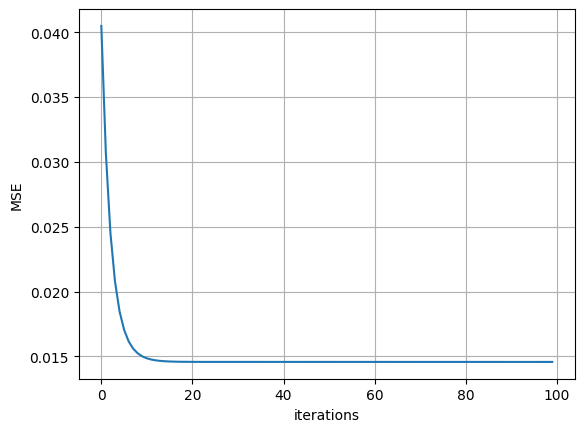

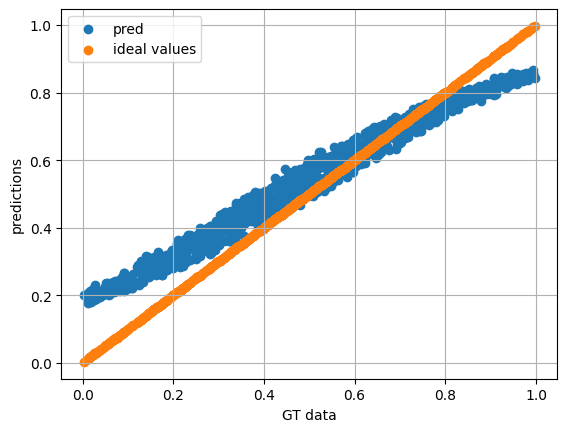

In [8]:
plt.plot(np.arange(iterations),errors)
plt.xlabel('iterations')
plt.grid()

plt.ylabel('MSE')
plt.show()

predictions = model.forward(data_input)
plt.scatter(output[:,0],predictions,  label='pred')
plt.scatter(output[:,0],output[:,0],  label='ideal values')

plt.legend()
plt.xlabel("GT data")
plt.ylabel("predictions")
plt.grid()


In [9]:
data_input = ### CODE HERE
n_layers =4
model = SingleInputMultiLayerNetwork(n_layers=n_layers,
                                     list_activation_functions=[Sigmoid() for i in range(n_layers)])
loss = MSE()

# print("MODEL {}".format(model))
iterations = 100
errors = np.zeros([iterations])

batch_size = 32

best_error = 100
best_model = model.copy()
for i in range(iterations):
    erro_iteration = []
    for id_batch in range(0,len(data_input),batch_size):
        next_batch = min(id_batch+batch_size,len(data_input))
        x = ### CODE HERE
        predictions_x = model.forward(x)
        error = loss.forward(output[id_batch:next_batch,0],predictions_x)
        erro_iteration += [np.mean(error)]

        derivative = loss.backward()
        model.backward(derivative)

        if errors[i] > 5000:
            print("Error found at {:d}".format(i))
            break

    errors[i] = np.mean(erro_iteration)
    if errors[i] < best_error:
        best_error = errors[i]
        best_model = model.copy()
# print("MODEL {}".format(model))

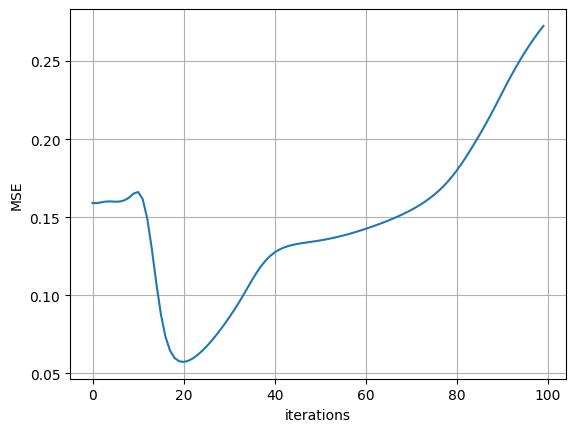

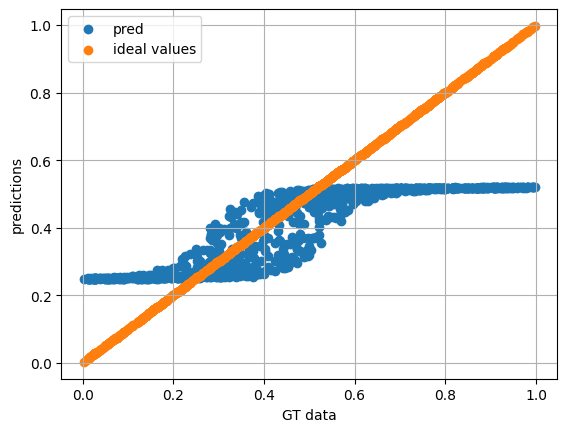

In [10]:
plt.plot(np.arange(iterations),errors)
plt.xlabel('iterations')
plt.grid()

plt.ylabel('MSE')
plt.show()

predictions = best_model.forward(data_input[:,-2])
plt.scatter(output[:,0],predictions,  label='pred')
plt.scatter(output[:,0],output[:,0],  label='ideal values')

plt.legend()
plt.xlabel("GT data")
plt.ylabel("predictions")
plt.grid()


## Parte 4: Análisis 
1. ¿Qué modelo presentó mejores resultados?
2. Para este problema, que consecuencia tiene que la red de un input solo pueda ver uno de los atributos. 
3. Comente sobre pros y cons del uso de la función de activación ReLU vs Sigmoide. ¿Qué problemas encontró? 
